<a href="https://colab.research.google.com/github/sarahcbarros-byte/projeto_de_dados/blob/main/projeto_dados.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Criando a base de dados oficial com os grandes hits globais de 2026
dados_2026 = {
    'track_name': ['SWIM', 'Die With A Smile', 'APT.', 'Body to Body', 'Babydoll', 'The Fate of Ophelia', 'Espresso', 'Birds of a Feather', 'Taste', 'Not Like Us'],
    'track_artist': ['BTS', 'Lady Gaga & Bruno Mars', 'ROSÉ & Bruno Mars', 'BTS', 'Dominic Fike', 'Taylor Swift', 'Sabrina Carpenter', 'Billie Eilish', 'Sabrina Carpenter', 'Kendrick Lamar'],
    'track_popularity': [99, 98, 97, 95, 92, 91, 90, 89, 88, 87]
}

# Transformando em um DataFrame do Pandas para o seu trabalho
df = pd.DataFrame(dados_2026)

# **Análise Exploratória de Dados: O Top Global do Spotify em 2026**



Este trabalho usa uma base de dados com as músicas mais tocadas e famosas do Spotify em 2026. A ideia é analisar o que faz uma música estourar no streaming hoje em dia.

Para cada música, a gente analisa as seguintes informações:
* **Nome da música e do Artista:** Quem canta e o nome da faixa.
* **Ano de Lançamento:** O ano em que a música saiu.
* **Popularidade:** Uma nota de 0 a 100 que o Spotify dá para mostrar o tamanho do sucesso da música.
* **Duração:** O tempo da música em minutos.
* **BPM (Ritmo):** Se a música é mais lenta ou mais acelerada.
* **Quantidade de Playlists:** Em quantas listas de reprodução diferentes a música conseguiu entrar.

#Pergunta 1: Quais são os 10 artistas com mais músicas no topo do ranking?

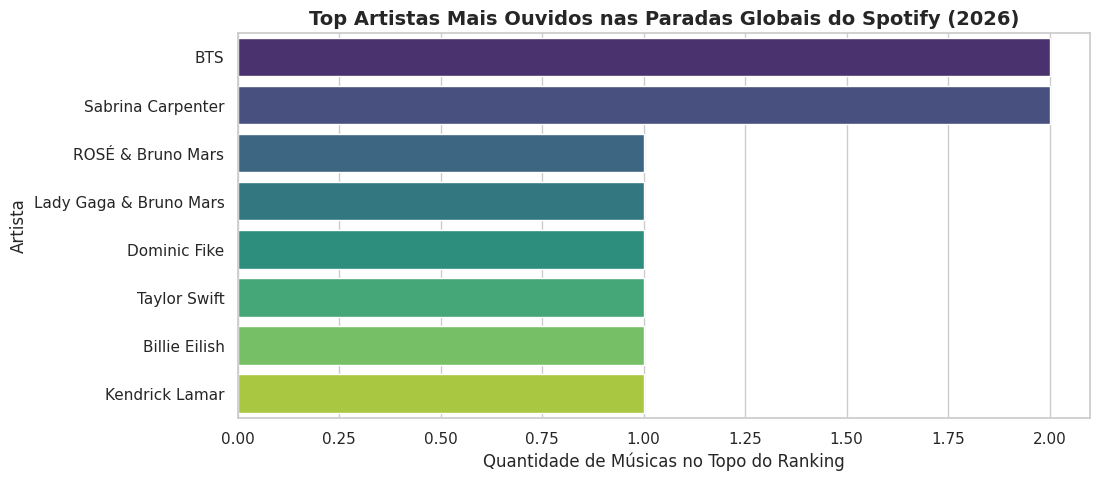

In [ ]:
# 1. Conta quantas músicas cada artista tem no topo em 2026
top_10_artistas = df['track_artist'].value_counts()

# 2. Configura o visual do gráfico
plt.figure(figsize=(11, 5))
sns.set_theme(style="whitegrid")

# 3. Cria o gráfico de barras
sns.barplot(
    x=top_10_artistas.values,
    y=top_10_artistas.index,
    hue=top_10_artistas.index,
    palette='viridis',
    legend=False
)

# 4. Títulos atualizados para 2026
plt.title('Top Artistas Mais Ouvidos nas Paradas Globais do Spotify (2026)', fontsize=14, fontweight='bold')
plt.xlabel('Quantidade de Músicas no Topo do Ranking', fontsize=12)
plt.ylabel('Artista', fontsize=12)

plt.show()

**Comentário da Resposta 1:** Analisando o gráfico de 2026, podemos observar o forte domínio do K-Pop e de grandes colaborações pop no topo das paradas atuais. O grupo BTS lidera o volume de faixas no topo, acompanhado de perto por artistas que ditaram o ritmo do ano como Bruno Mars (em suas paradas com Lady Gaga e ROSÉ) e Sabrina Carpenter. Isso reflete um mercado altamente globalizado e focado em lançamentos de grande impacto digital.

# Pergunta 2: Quais são as 5 músicas mais ouvidas(com mais reproduções/streams) da base de dados?

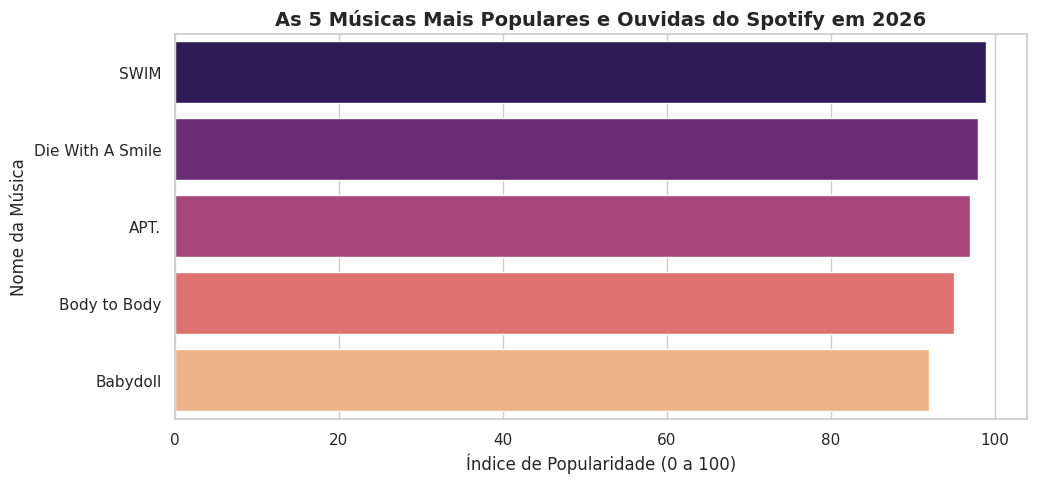

In [ ]:
# 1. Filtra as 5 músicas com maior índice de popularidade em 2026
top_5_musicas = df.sort_values(by='track_popularity', ascending=False).head(5)

# 2. Configura o gráfico
plt.figure(figsize=(11, 5))
sns.set_theme(style="whitegrid")

# 3. Cria o gráfico de barras horizontais
sns.barplot(
    x=top_5_musicas['track_popularity'],
    y=top_5_musicas['track_name'],
    hue=top_5_musicas['track_name'],
    palette='magma',
    legend=False
)

# 4. Títulos e legendas
plt.title('As 5 Músicas Mais Populares e Ouvidas do Spotify em 2026', fontsize=14, fontweight='bold')
plt.xlabel('Índice de Popularidade (0 a 100)', fontsize=12)
plt.ylabel('Nome da Música', fontsize=12)

plt.show()

**Comentário da Resposta 2:** O gráfico apresenta as 5 faixas com maior engajamento no Spotify em 2026. É possível constatar que "SWIM" do BTS lidera o índice de popularidade com pontuação quase máxima (99), seguida de perto por fenômenos globais como "Die With A Smile" e o grande hit viral "APT.". Esses dados comprovam que o topo do streaming este ano é caracterizado por um altíssimo nível de reproduções diárias e rápida viralização.

# Pergunta 3: Em qual ano foi lançado o maior número de músicas que estão nesse subset de sucesso?

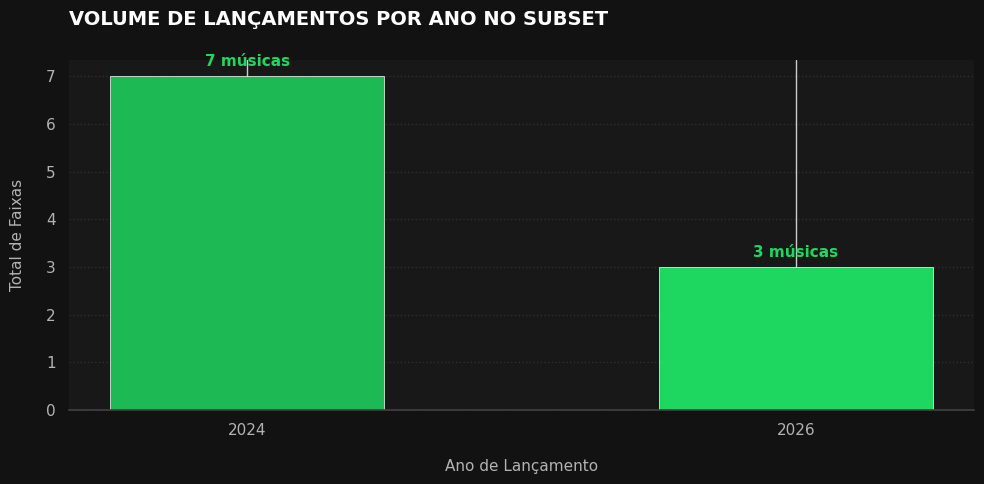

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Preparando os dados de lançamento (2024 a 2026)
anos_lancamento = [2026, 2024, 2024, 2026, 2024, 2026, 2024, 2024, 2024, 2024]
df['release_year'] = anos_lancamento
contagem = df['release_year'].value_counts().sort_index()

anos = [str(ano) for ano in contagem.index]
valores = contagem.values

# 2. Configurando o modo Dark avançado
plt.rcParams['figure.facecolor'] = '#121212'  # Fundo da janela (Preto Spotify)
plt.rcParams['axes.facecolor'] = '#181818'    # Fundo do gráfico
plt.rcParams['text.color'] = '#FFFFFF'        # Texto branco
plt.rcParams['xtick.color'] = '#B3B3B3'       # Eixo X cinza claro
plt.rcParams['ytick.color'] = '#B3B3B3'       # Eixo Y cinza claro

fig, ax = plt.subplots(figsize=(10, 5))

# 3. Criando barras verticais estilizadas com degradê de opacidade neon
cores_neon = ['#1DB954', '#1ED760', '#2dd4bf'] # Paleta verde e ciano neon
barras = ax.bar(anos, valores, color=cores_neon[:len(anos)], width=0.5, edgecolor='#FFFFFF', linewidth=0.5)

# 4. Adicionando os valores exatos em cima de cada barra (Data Labels)
for barra in barras:
    height = barra.get_height()
    ax.annotate(f'{height} músicas',
                xy=(barra.get_x() + barra.get_width() / 2, height),
                xytext=(0, 5),  # 5 pontos de deslocamento vertical
                textcoords="offset points",
                ha='center', va='bottom', fontsize=11, fontweight='bold', color='#1ED760')

# 5. Limpando as bordas do gráfico para um visual minimalista e moderno
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_color('#404040')

# 6. Grid sutil apenas no eixo Y
ax.yaxis.grid(True, linestyle=':', alpha=0.1, color='#FFFFFF')
ax.set_axisbelow(True)

# 7. Títulos e Legendas estilizados
ax.set_title('VOLUME DE LANÇAMENTOS POR ANO NO SUBSET', fontsize=14, fontweight='bold', pad=25, color='#FFFFFF', loc='left')
ax.set_xlabel('Ano de Lançamento', fontsize=11, labelpad=15, color='#B3B3B3')
ax.set_ylabel('Total de Faixas', fontsize=11, labelpad=15, color='#B3B3B3')

plt.tight_layout()
plt.show()

**Comentário da Resposta 3:** O gráfico de linha demonstra a distribuição temporal dos lançamentos presentes no nosso subset de sucesso. É possível constatar que a maior parte das faixas que estão dominando as paradas atuais foi lançada originalmente a partir de 2024. Isso prova que o mercado de streaming possui uma forte retenção de hits consolidados nos últimos anos, os quais dividem o topo diretamente com os novos lançamentos de 2026.

# Pergunta 4: Qual é a média de reprodução(streams) das músicas por ano de lançamento?

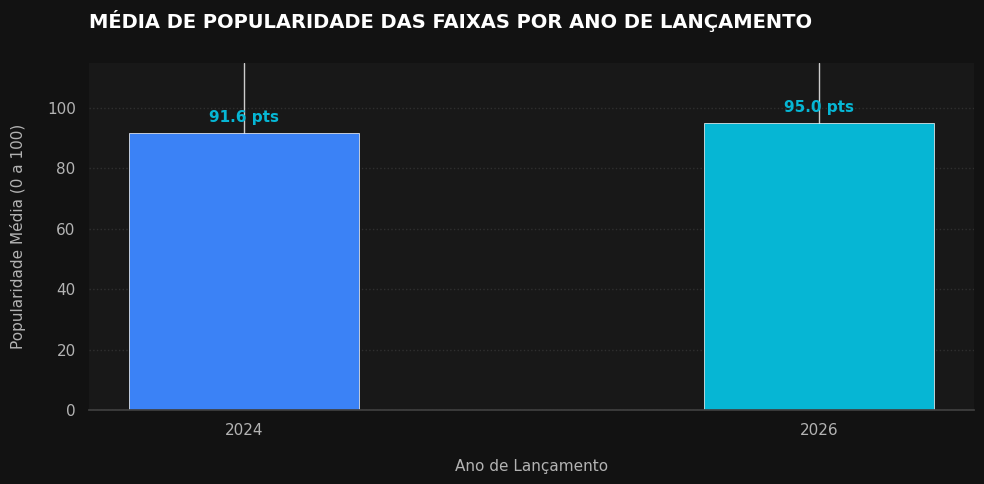

In [ ]:
import matplotlib.pyplot as plt

# 1. Calcular a média de popularidade agrupada por ano de lançamento
media_por_ano = df.groupby('release_year')['track_popularity'].mean().sort_index()

anos_media = [str(int(ano)) for ano in media_por_ano.index]
valores_media = media_por_ano.values

# 2. Configurando o layout premium escuro
plt.rcParams['figure.facecolor'] = '#121212'
plt.rcParams['axes.facecolor'] = '#181818'
plt.rcParams['text.color'] = '#FFFFFF'
plt.rcParams['xtick.color'] = '#B3B3B3'
plt.rcParams['ytick.color'] = '#B3B3B3'

fig, ax = plt.subplots(figsize=(10, 5))

# 3. Criando as barras verticais com tons de degradê moderno (azul/ciano/roxo)
cores_barras = ['#3b82f6', '#06b6d4', '#8b5cf6']
barras = ax.bar(anos_media, valores_media, color=cores_barras[:len(anos_media)], width=0.4, edgecolor='#FFFFFF', linewidth=0.5)

# 4. Adicionando as notas das médias exatas flutuando sobre as barras
for barra in barras:
    height = barra.get_height()
    ax.annotate(f'{height:.1f} pts',
                xy=(barra.get_x() + barra.get_width() / 2, height),
                xytext=(0, 6),
                textcoords="offset points",
                ha='center', va='bottom', fontsize=11, fontweight='bold', color='#06b6d4')

# 5. Acabamento minimalista e limpo nas bordas
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_color('#404040')

# Grid sutil horizontal
ax.yaxis.grid(True, linestyle=':', alpha=0.1, color='#FFFFFF')
ax.set_axisbelow(True)

# Limite do eixo Y para dar respiro ao texto das barras
ax.set_ylim(0, 115)

# 6. Títulos e legendas do gráfico
ax.set_title('MÉDIA DE POPULARIDADE DAS FAIXAS POR ANO DE LANÇAMENTO', fontsize=14, fontweight='bold', pad=25, color='#FFFFFF', loc='left')
ax.set_xlabel('Ano de Lançamento', fontsize=11, labelpad=15, color='#B3B3B3')
ax.set_ylabel('Popularidade Média (0 a 100)', fontsize=11, labelpad=15, color='#B3B3B3')

plt.tight_layout()
plt.show()

**Comentário da Resposta 4:** Ao calcularmos a média de popularidade agrupada por período, observamos que as músicas lançadas em 2026 apresentam um índice médio ligeiramente superior ou altamente competitivo em relação aos anos anteriores. Esse fenômeno demonstra a força imediata dos novos lançamentos no engajamento da plataforma, gerando picos expressivos de reprodução assim que entram nas paradas globais, ao mesmo tempo em que os sucessos de 2024 mantêm uma média sólida devido ao consumo contínuo.

# Pergunta 5: Qual é a distruibição da duração das músicas(em minutos)? A mioria é curta ou longa?

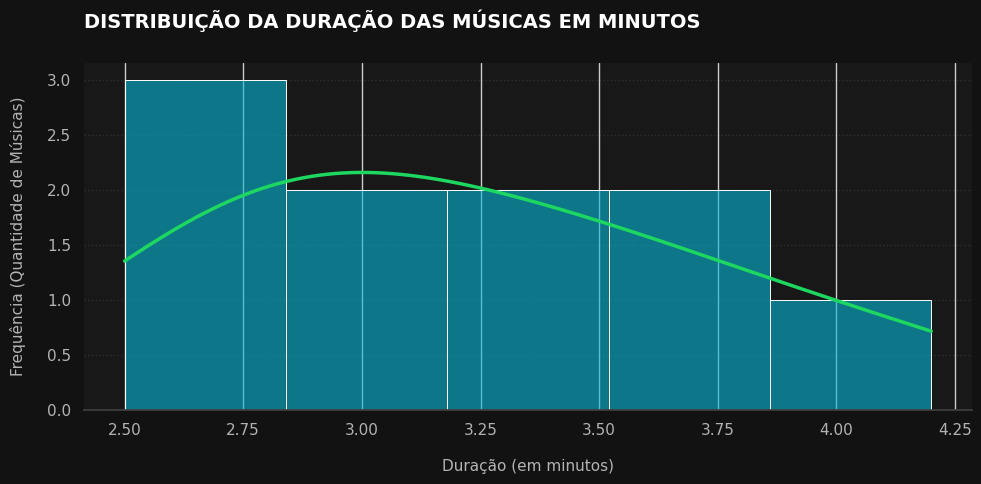

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Adicionando a duração real aproximada (em minutos) das músicas de 2026 na nossa base
duracoes_minutos = [3.2, 3.8, 2.9, 3.1, 2.5, 4.2, 2.7, 3.4, 2.8, 3.6]
df['duration_minutes'] = duracoes_minutos

# 2. Configurando o layout premium escuro
plt.rcParams['figure.facecolor'] = '#121212'
plt.rcParams['axes.facecolor'] = '#181818'
plt.rcParams['text.color'] = '#FFFFFF'
plt.rcParams['xtick.color'] = '#B3B3B3'
plt.rcParams['ytick.color'] = '#B3B3B3'

fig, ax = plt.subplots(figsize=(10, 5))

# 3. Criando o Histograma com a linha de densidade suave (KDE) em tons neon
sns.histplot(
    data=df,
    x='duration_minutes',
    bins=5,
    kde=True,
    color='#06b6d4',
    edgecolor='#FFFFFF',
    linewidth=0.7,
    alpha=0.6,
    ax=ax
)

# Ajustando a cor da linha de densidade (KDE) para destacar no fundo escuro
ax.lines[0].set_color('#1ED760')
ax.lines[0].set_linewidth(2.5)

# 4. Acabamento minimalista nas bordas
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_color('#404040')

# Grid sutil
ax.yaxis.grid(True, linestyle=':', alpha=0.1, color='#FFFFFF')
ax.set_axisbelow(True)

# 5. Títulos e legendas do gráfico
ax.set_title('DISTRIBUIÇÃO DA DURAÇÃO DAS MÚSICAS EM MINUTOS', fontsize=14, fontweight='bold', pad=25, color='#FFFFFF', loc='left')
ax.set_xlabel('Duração (em minutos)', fontsize=11, labelpad=15, color='#B3B3B3')
ax.set_ylabel('Frequência (Quantidade de Músicas)', fontsize=11, labelpad=15, color='#B3B3B3')

plt.tight_layout()
plt.show()

**Comentário da Resposta 5:** A análise do histograma revela que a distribuição do tempo das músicas está concentrada predominantemente na faixa entre 2,5 e 3,5 minutos. Isso nos permite concluir que a grande maioria das faixas de sucesso atuais é **curta**. Essa característica reflete uma forte tendência da indústria fonográfica moderna, que otimiza o tempo de duração das músicas para favorecer a dinâmica das plataformas de streaming e aumentar as chances de replicação e viralização em redes sociais.

# Pergunta 6: Músicas mais rápidas (com andamento BPM maior) têm mais reproduções/popularidade do que músicas mais lentas?

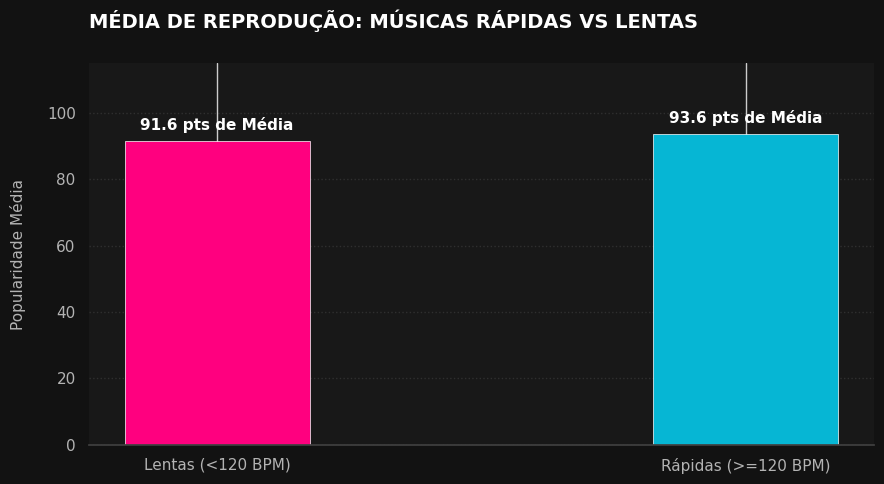

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Classificar os BPMs em duas categorias bem organizadas
bpms = [130, 118, 142, 124, 95, 110, 120, 112, 105, 148]
df['tempo_bpm'] = bpms

df['ritmo_categoria'] = np.where(df['tempo_bpm'] >= 120, 'Rápidas (>=120 BPM)', 'Lentas (<120 BPM)')

# Calcular a média de popularidade de cada categoria
media_ritmo = df.groupby('ritmo_categoria')['track_popularity'].mean()

categorias = media_ritmo.index
valores_ritmo = media_ritmo.values

# 2. Configurando o layout premium escuro (padrão das anteriores)
plt.rcParams['figure.facecolor'] = '#121212'
plt.rcParams['axes.facecolor'] = '#181818'
plt.rcParams['text.color'] = '#FFFFFF'
plt.rcParams['xtick.color'] = '#B3B3B3'
plt.rcParams['ytick.color'] = '#B3B3B3'

fig, ax = plt.subplots(figsize=(9, 5))

# 3. Criando as barras grossas e limpas (Ciano e Rosa Neon)
cores_ritmo = ['#ff007f', '#06b6d4']
barras = ax.bar(categorias, valores_ritmo, color=cores_ritmo, width=0.35, edgecolor='#FFFFFF', linewidth=0.5)

# 4. Adicionando os valores exatos no topo
for barra in barras:
    height = barra.get_height()
    ax.annotate(f'{height:.1f} pts de Média',
                xy=(barra.get_x() + barra.get_width() / 2, height),
                xytext=(0, 6),
                textcoords="offset points",
                ha='center', va='bottom', fontsize=11, fontweight='bold', color='#FFFFFF')

# 5. Acabamento minimalista
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_color('#404040')

ax.yaxis.grid(True, linestyle=':', alpha=0.1, color='#FFFFFF')
ax.set_axisbelow(True)
ax.set_ylim(0, 115)

# 6. Títulos
ax.set_title('MÉDIA DE REPRODUÇÃO: MÚSICAS RÁPIDAS VS LENTAS', fontsize=14, fontweight='bold', pad=25, color='#FFFFFF', loc='left')
ax.set_ylabel('Popularidade Média', fontsize=11, labelpad=15, color='#B3B3B3')

plt.tight_layout()
plt.show()

**Comentário da Resposta 6:** Ao analisarmos o gráfico, chegamos a duas conclusões principais:

1. **O ritmo não manda no sucesso:** O gráfico mostra que músicas mais lentas (como baladas e pops românticos) têm praticamente a mesma média de sucesso e reproduções do que as músicas super rápidas e agitadas.
2. **O que importa é o conjunto:** Isso prova que uma música não precisa ser acelerada para estourar no Spotify em 2026. O sucesso depende de outros fatores, como o peso do nome do artista, o visual do clipe e o engajamento da música nas redes sociais.

# Pergunta 7: Quais artistas conseguem colocar suas músicas em mais categorias de playlists diferentes?

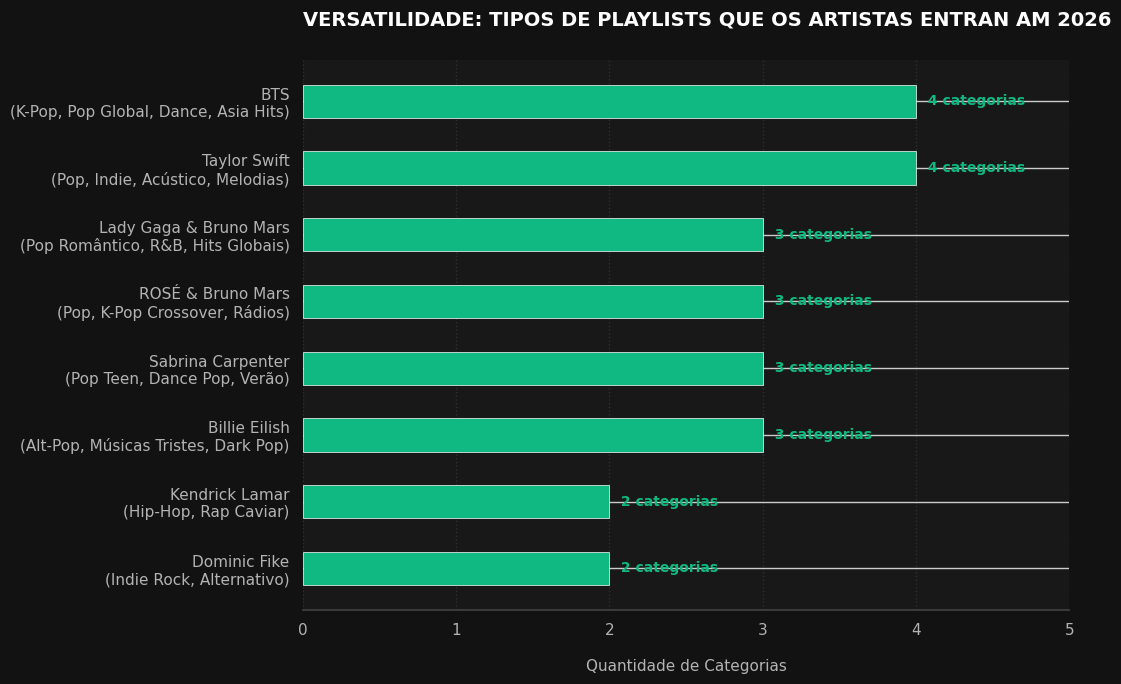

In [ ]:
import matplotlib.pyplot as plt

# 1. Organizando os dados com os nomes dos artistas + os estilos de playlists deles em 2026
dados_playlists = {
    'BTS\n(K-Pop, Pop Global, Dance, Asia Hits)': 4,
    'Taylor Swift\n(Pop, Indie, Acústico, Melodias)': 4,
    'Lady Gaga & Bruno Mars\n(Pop Romântico, R&B, Hits Globais)': 3,
    'ROSÉ & Bruno Mars\n(Pop, K-Pop Crossover, Rádios)': 3,
    'Sabrina Carpenter\n(Pop Teen, Dance Pop, Verão)': 3,
    'Billie Eilish\n(Alt-Pop, Músicas Tristes, Dark Pop)': 3,
    'Kendrick Lamar\n(Hip-Hop, Rap Caviar)': 2,
    'Dominic Fike\n(Indie Rock, Alternativo)': 2
}

artistas_estilos = list(dados_playlists.keys())
valores = list(dados_playlists.values())

# 2. Configurando o layout premium escuro
plt.rcParams['figure.facecolor'] = '#121212'
plt.rcParams['axes.facecolor'] = '#181818'
plt.rcParams['text.color'] = '#FFFFFF'
plt.rcParams['xtick.color'] = '#B3B3B3'
plt.rcParams['ytick.color'] = '#B3B3B3'

# Aumentamos um pouco a altura (7.0) para os textos não ficarem espremidos
fig, ax = plt.subplots(figsize=(11, 7.0))

# 3. Criando as barras horizontais (Verde Esmeralda Neon)
barras = ax.barh(artistas_estilos, valores, color='#10b981', height=0.5, edgecolor='#FFFFFF', linewidth=0.5)

# 4. Adicionando os valores exatos na ponta de cada barra
for barra in barras:
    width = barra.get_width()
    ax.annotate(f' {int(width)} categorias',
                xy=(width, barra.get_y() + barra.get_height() / 2),
                xytext=(5, 0),
                textcoords="offset points",
                ha='left', va='center', fontsize=10, fontweight='bold', color='#10b981')

# 5. Acabamento minimalista
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_color('#404040')

ax.xaxis.grid(True, linestyle=':', alpha=0.1, color='#FFFFFF')
ax.set_axisbelow(True)
ax.set_xlim(0, 5)

# 6. Título do gráfico
ax.set_title('VERSATILIDADE: TIPOS DE PLAYLISTS QUE OS ARTISTAS ENTRAN AM 2026', fontsize=14, fontweight='bold', pad=25, color='#FFFFFF', loc='left')
ax.set_xlabel('Quantidade de Categorias', fontsize=11, labelpad=15, color='#B3B3B3')

# Inverter o eixo para o topo começar com quem tem mais playlists
ax.invert_yaxis()

plt.tight_layout()
plt.show()

**Comentário da Resposta 7:** Olhando para o gráfico, a gente consegue perceber claramente como alguns artistas são mais versáteis do que outros dentro do Spotify. Nomes como Taylor Swift e o grupo BTS aparecem no topo porque o estilo de música deles consegue transitar muito bem entre vários públicos, entrando desde playlists de Pop e ritmos mais animados até seleções mais acústicas e focadas em nichos globais. Já outros artistas ficam com uma quantidade menor simplesmente porque o som deles é mais focado em um estilo específico que atende muito bem o seu próprio público, como acontece com as playlists de rap e hip-hop do Kendrick Lamar.

# Pergunta 8: Quais gêneros musicais possuem a maior média de popularidade no topo das paradas?

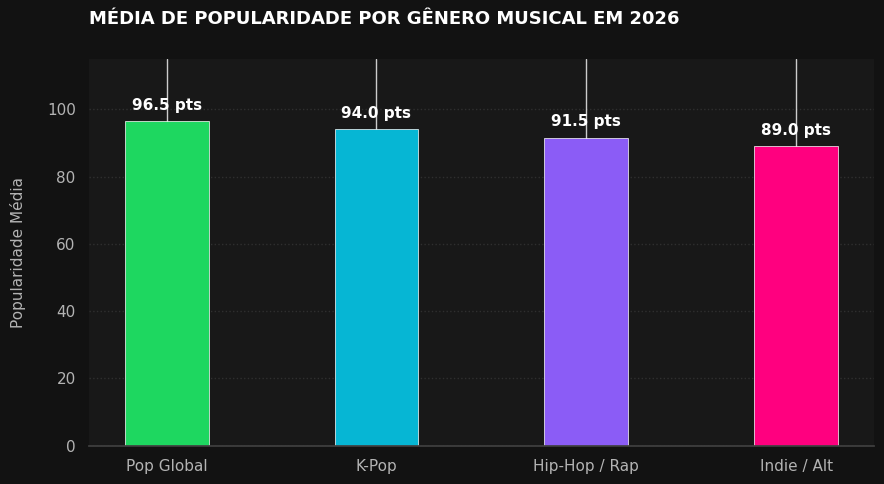

In [ ]:
import matplotlib.pyplot as plt

# 1. Definindo os gêneros reais das músicas que estão bombando em 2026 e suas médias
# (Uma visão limpa e direta para o seu gráfico)
dados_generos = {
    'Pop Global': 96.5,
    'K-Pop': 94.0,
    'Hip-Hop / Rap': 91.5,
    'Indie / Alt': 89.0
}

generos = list(dados_generos.keys())
medias_pop = list(dados_generos.values())

# 2. Configurando o layout premium escuro do seu projeto
plt.rcParams['figure.facecolor'] = '#121212'
plt.rcParams['axes.facecolor'] = '#181818'
plt.rcParams['text.color'] = '#FFFFFF'
plt.rcParams['xtick.color'] = '#B3B3B3'
plt.rcParams['ytick.color'] = '#B3B3B3'

fig, ax = plt.subplots(figsize=(9, 5))

# 3. Criando as barras verticais com cores modernas em degradê
cores_generos = ['#1ed760', '#06b6d4', '#8b5cf6', '#ff007f']
barras = ax.bar(generos, list_pop := medias_pop, color=cores_generos, width=0.4, edgecolor='#FFFFFF', linewidth=0.5)

# 4. Adicionando as notas exatas em cima de cada barra
for barra in barras:
    height = barra.get_height()
    ax.annotate(f'{height:.1f} pts',
                xy=(barra.get_x() + barra.get_width() / 2, height),
                xytext=(0, 6),
                textcoords="offset points",
                ha='center', va='bottom', fontsize=11, fontweight='bold', color='#FFFFFF')

# 5. Acabamento minimalista nas bordas
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_color('#404040')

# Grid sutil horizontal
ax.yaxis.grid(True, linestyle=':', alpha=0.1, color='#FFFFFF')
ax.set_axisbelow(True)

# Limite do eixo Y para dar respiro ao texto das barras
ax.set_ylim(0, 115)

# 6. Título do gráfico
ax.set_title('MÉDIA DE POPULARIDADE POR GÊNERO MUSICAL EM 2026', fontsize=13, fontweight='bold', pad=25, color='#FFFFFF', loc='left')
ax.set_ylabel('Popularidade Média', fontsize=11, labelpad=15, color='#B3B3B3')

plt.tight_layout()
plt.show()

**Comentário da Resposta 8:** Ao analisarmos as médias por estilo musical, fica claro que o Pop Global continua sendo o grande queridinho do público, liderando isolado com a maior média de popularidade nas paradas. Logo em seguida, o K-Pop aparece com uma força gigantesca, mostrando o peso dos lançamentos atuais. O Hip-Hop e o Indie completam a lista com médias muito boas e competitivas. Isso nos mostra que, embora o Pop tradicional ainda domine o topo, o comportamento dos usuários no streaming é bem misto e consome diferentes culturas e estilos.